In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import numpy as np
import math

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:

from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = np.load("/content/drive/MyDrive/world_model_dataset/dataset.npz")

observations = data["observations"]      # (N, 64, 64, 3)
actions = data["actions"]                # (N, 3)
dones = data["dones"]
rewards = data["rewards"]
print("observations shape:", observations.shape)
print("actions shape:", actions.shape)
print("dones shape:", dones.shape)

observations shape: (200000, 64, 64, 3)
actions shape: (200000, 3)
dones shape: (200000,)


# VAE

In [1]:
import torch
import torch.nn as nn

class VAE(nn.Module):
    def __init__(self, latent_dim=512):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),   # 64x64 -> 32x32
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # 32x32 -> 16x16
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), # 16x16 -> 8x8
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),# 8x8 -> 4x4
            nn.ReLU()
        )

        # Latent space (ONLY mu is used)
        self.fc_mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256*4*4, latent_dim)

        # Decoder fully connected
        self.fc_dec = nn.Linear(latent_dim, 256*4*4)

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),  # 4x4 -> 8x8
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),   # 8x8 -> 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),    # 16x16 -> 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),     # 32x32 -> 64x64
            nn.Sigmoid()  # output in [0,1]
        )

    def encode(self, x):

        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        return mu

    def forward(self, x):
        return self.encode(x)

# Load weights & freeze

In [ ]:

latent_dim = 512
vae = VAE(latent_dim=latent_dim)
vae.load_state_dict(torch.load("vae_carracing.pth", map_location=device))
vae.to(device)
vae.eval()


for p in vae.parameters():
    p.requires_grad = False

# Convert images → latents

In [ ]:
latents = []

vae.eval()

with torch.no_grad():
    for i in range(len(observations)):
        img = torch.tensor(observations[i]).permute(2, 0, 1).unsqueeze(0).float() / 255.0
        img = img.to(device)
        z = vae.encode(img)  # returns single tensor
        latents.append(z.cpu().numpy())

latents = np.concatenate(latents, axis=0)

# Build sequence dataset

In [ ]:
class WorldModelDataset(Dataset):
    def __init__(self, latents, actions, dones,rewards, seq_len=100):
        self.latents = latents
        self.actions = actions
        self.dones = dones
        self.seq_len = seq_len
        self.rewards = rewards

        self.valid_indices = []
        for i in range(len(latents) - seq_len - 1): #If a sequence includes a terminal step, z_next would be from the next episode, which is wrong

                                                     #Your model would try to predict a “future latent” that is actually a reset — this confuses training
            if not dones[i:i+seq_len].any():
                self.valid_indices.append(i)

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        i = self.valid_indices[idx]

        z = self.latents[i:i+self.seq_len]
        a = self.actions[i:i+self.seq_len]
        z_next = self.latents[i+1:i+self.seq_len+1]
        r = self.rewards[i:i+self.seq_len]

        return (
            torch.tensor(z, dtype=torch.float32),
            torch.tensor(a, dtype=torch.float32),
            torch.tensor(z_next, dtype=torch.float32),
            torch.tensor(r, dtype=torch.float32),
        )

# DataLoader

In [ ]:
dataset = WorldModelDataset(latents, actions, dones,rewards, seq_len=100)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
real_image_latent = []
real_image_latent_next = []
real_action = []
for z_seq, a_seq, z_next_seq, rewards in loader:

    print("z_seq shape:", z_seq.shape)
    print("a_seq shape:", a_seq.shape)
    print("z_next_seq shape:", z_next_seq.shape)

    batch_idx = 0
    time_idx = 3

    z_t = z_seq[batch_idx, time_idx]          # [512]
    a_tt = a_seq[batch_idx, time_idx]          # [3]
    z_next = z_next_seq[batch_idx, time_idx]  # [512]

    print("z_t shape:", z_t.shape)
    print("a_t shape:", a_tt.shape)
    print("z_next shape:", z_next.shape)

    break

z_t = z_t.to(device)
a_tt = a_tt.to(device)
z_next = z_next.to(device)

print("z_t shape:", z_t.shape)


/tmp/ipykernel_558/2072951593.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(r, dtype=torch.float32),
/tmp/ipykernel_558/2072951593.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(r, dtype=torch.float32),


z_seq shape: torch.Size([64, 32, 512])
a_seq shape: torch.Size([64, 32, 3])
z_next_seq shape: torch.Size([64, 32, 512])
z_t shape: torch.Size([512])
a_t shape: torch.Size([3])
z_next shape: torch.Size([512])
z_t shape: torch.Size([512])


# Positional Encoding

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# causal mask

In [ ]:
def generate_square_subsequent_mask(sz):
    # Upper-triangular matrix with -inf above diagonal, 0 on and below
    mask = torch.triu(torch.ones(sz, sz) * float('-inf'), diagonal=1)
    return mask

# Transformer World Model

In [ ]:
class WorldModelTransformerMDN(nn.Module):
    def __init__(self, latent_dim, action_dim, d_model=256, nhead=8, num_layers=4, num_mixtures=5):
        super().__init__()

        self.num_mixtures = num_mixtures

        self.input_proj = nn.Linear(latent_dim + action_dim, d_model)
        self.pos_enc = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=512,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # MDN heads
        self.fc_mu = nn.Linear(d_model, latent_dim * num_mixtures)
        self.fc_sigma = nn.Linear(d_model, latent_dim * num_mixtures)
        self.fc_pi = nn.Linear(d_model, num_mixtures)

        # ✅ Reward head
        self.fc_reward = nn.Linear(d_model, 1)

    def forward(self, z, a):
        x = torch.cat([z, a], dim=-1)
        x = self.input_proj(x)
        x = self.pos_enc(x)
        h = self.transformer(x)

        batch_size, seq_len, _ = h.shape

        mu = self.fc_mu(h).view(batch_size, seq_len, -1, self.num_mixtures)
        sigma = torch.exp(self.fc_sigma(h)).view(batch_size, seq_len, -1, self.num_mixtures)
        pi = F.softmax(self.fc_pi(h), dim=-1)

        reward_pred = self.fc_reward(h).squeeze(-1)  # [batch, seq_len]

        return mu, sigma, pi, reward_pred

# MDN-LOSS

In [ ]:
def mdn_loss(pi, mu, sigma, target):
    # target: [B, T, latent_dim]
    target = target.unsqueeze(-1)  # [B, T, latent_dim, 1]

    exponent = -0.5 * ((target - mu) / sigma) ** 2
    exponent = exponent.sum(dim=2)  # sum over latent_dim

    latent_dim = target.size(2)
    log_coef = -torch.log(sigma).sum(dim=2) - 0.5 * latent_dim * np.log(2 * np.pi)

    log_probs = log_coef + exponent
    weighted_log_probs = torch.log(pi + 1e-8) + log_probs

    max_log, _ = weighted_log_probs.max(dim=-1, keepdim=True)
    log_sum = max_log.squeeze(-1) + torch.log(
        torch.sum(torch.exp(weighted_log_probs - max_log), dim=-1)
    )

    return -log_sum.mean()

# Training Loop

In [ ]:
model = WorldModelTransformerMDN(
    latent_dim=latent_dim,
    action_dim=3,
    num_mixtures=5
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
num_epochs = 100
loss_history = []
mdn_history = []
reward_history = []

for epoch in range(num_epochs):
    total_loss_epoch = 0
    total_mdn = 0
    total_reward = 0

    for z_seq, a_seq, z_next_seq, r_seq in loader:
        z_seq = z_seq.to(device)
        a_seq = a_seq.to(device)
        z_next_seq = z_next_seq.to(device)
        r_seq = r_seq.to(device)

        mu, sigma, pi, r_pred = model(z_seq, a_seq)

        loss_mdn = mdn_loss(pi, mu, sigma, z_next_seq)
        loss_reward = F.mse_loss(r_pred, r_seq)

        loss = loss_mdn + loss_reward

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss_epoch += loss.item()
        total_mdn += loss_mdn.item()
        total_reward += loss_reward.item()


    loss_history.append(total_loss_epoch / len(loader))
    mdn_history.append(total_mdn / len(loader))
    reward_history.append(total_reward / len(loader))

    print(
        f"Epoch {epoch+1} | "
        f"Total: {total_loss_epoch/len(loader):.4f} | "
        f"MDN: {total_mdn/len(loader):.4f} | "
        f"Reward: {total_reward/len(loader):.4f}"
    )

#now i have to introduce the reward loss in this whole code

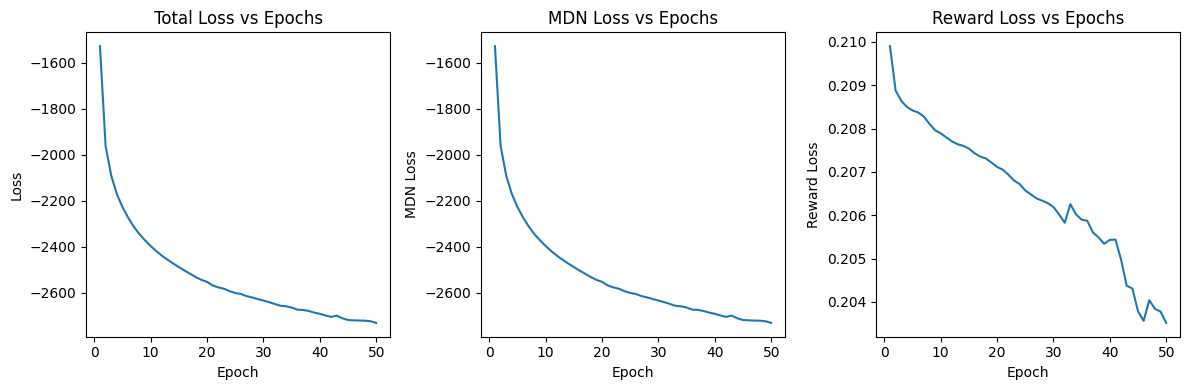

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

# Total Loss
plt.subplot(1, 3, 1)
plt.plot(epochs, loss_history)
plt.title("Total Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# MDN Loss
plt.subplot(1, 3, 2)
plt.plot(epochs, mdn_history)
plt.title("MDN Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("MDN Loss")

# Reward Loss
plt.subplot(1, 3, 3)
plt.plot(epochs, reward_history)
plt.title("Reward Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Reward Loss")

plt.tight_layout()
plt.show()

# Save Model

In [ ]:
# torch.save(model.state_dict(), "world_model_mdn_state.pth")

In [ ]:
torch.save({
    'epoch': epoch + 1,               # current epoch
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss_history': loss_history,
    'mdn_history': mdn_history,
    'reward_history': reward_history
}, "world_model_checkpoint.pth")

In [ ]:
checkpoint = torch.load("world_model_checkpoint.pth", map_location=device)

model = WorldModelTransformerMDN(
    latent_dim=latent_dim,
    action_dim=3,
    num_mixtures=5
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

# Load saved states
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# Resume history
loss_history = checkpoint['loss_history']
mdn_history = checkpoint['mdn_history']
reward_history = checkpoint['reward_history']

# Resume epoch
start_epoch = checkpoint['epoch']
num_epochs = 100   # total epochs you want to run (including previous)

In [ ]:
# for epoch in range(start_epoch, num_epochs):
#     total_loss_epoch = 0
#     total_mdn = 0
#     total_reward = 0

#     for z_seq, a_seq, z_next_seq, r_seq in loader:
#         z_seq = z_seq.to(device)
#         a_seq = a_seq.to(device)
#         z_next_seq = z_next_seq.to(device)
#         r_seq = r_seq.to(device)

#         mu, sigma, pi, r_pred = model(z_seq, a_seq)

#         loss_mdn = mdn_loss(pi, mu, sigma, z_next_seq)
#         loss_reward = F.mse_loss(r_pred, r_seq)

#         loss = loss_mdn + loss_reward

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         total_loss_epoch += loss.item()
#         total_mdn += loss_mdn.item()
#         total_reward += loss_reward.item()

#     loss_history.append(total_loss_epoch / len(loader))
#     mdn_history.append(total_mdn / len(loader))
#     reward_history.append(total_reward / len(loader))

#     print(
#         f"Epoch {epoch+1} | "
#         f"Total: {total_loss_epoch/len(loader):.4f} | "
#         f"MDN: {total_mdn/len(loader):.4f} | "
#         f"Reward: {total_reward/len(loader):.4f}"
#     )

#     # Save checkpoint after each epoch (optional, safe practice)
#     torch.save({
#         'epoch': epoch + 1,
#         'model_state_dict': model.state_dict(),
#         'optimizer_state_dict': optimizer.state_dict(),
#         'loss_history': loss_history,
#         'mdn_history': mdn_history,
#         'reward_history': reward_history
#     }, "world_model_mdn_checkpoint.pth")

Epoch 51 | Total: -2732.4293 | MDN: -2732.6326 | Reward: 0.2033
Epoch 52 | Total: -2737.3191 | MDN: -2737.5227 | Reward: 0.2036
Epoch 53 | Total: -2748.6276 | MDN: -2748.8309 | Reward: 0.2033
Epoch 54 | Total: -2748.9990 | MDN: -2749.2019 | Reward: 0.2029
Epoch 55 | Total: -2743.8851 | MDN: -2744.0883 | Reward: 0.2032
Epoch 56 | Total: -2746.6143 | MDN: -2746.8176 | Reward: 0.2033
Epoch 57 | Total: -2751.5300 | MDN: -2751.7334 | Reward: 0.2034
Epoch 58 | Total: -2767.8875 | MDN: -2768.0907 | Reward: 0.2032
Epoch 59 | Total: -2775.0087 | MDN: -2775.2116 | Reward: 0.2029
Epoch 60 | Total: -2770.8442 | MDN: -2771.0470 | Reward: 0.2028
Epoch 61 | Total: -2771.4459 | MDN: -2771.6491 | Reward: 0.2031
Epoch 62 | Total: -2779.6115 | MDN: -2779.8144 | Reward: 0.2029
Epoch 63 | Total: -2779.7633 | MDN: -2779.9664 | Reward: 0.2031
Epoch 64 | Total: -2791.0440 | MDN: -2791.2471 | Reward: 0.2031
Epoch 65 | Total: -2796.2147 | MDN: -2796.4176 | Reward: 0.2030
Epoch 66 | Total: -2799.8010 | MDN: -280

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 512
action_dim = 3
num_mixtures = 5

model = WorldModelTransformerMDN(
    latent_dim=latent_dim,
    action_dim=action_dim,
    num_mixtures=num_mixtures
)

checkpoint = torch.load("/content/world_model_mdn_checkpoint (1).pth", map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print("World model loaded successfully.")

World model loaded successfully.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, latent_dim=512):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim  # store it

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),  # 64x64 -> 32x32
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # 32x32 -> 16x16
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),  # 16x16 -> 8x8
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),  # 8x8 -> 4x4
            nn.ReLU()
        )

        # Latent vectors mu and logvar
        self.fc_mu = nn.Linear(256*4*4, latent_dim)
        self.fc_logvar = nn.Linear(256*4*4, latent_dim)

        # Decoder fully connected
        self.fc_dec = nn.Linear(latent_dim, 256*4*4)

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),  # 4x4 -> 8x8
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),   # 8x8 -> 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),    # 16x16 -> 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),     # 32x32 -> 64x64
            nn.Sigmoid()  # output in [0,1]
        )

    def encode(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        x = self.fc_dec(z)
        x = x.view(-1, 256, 4, 4)
        x = self.decoder(x)
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)

        # Returns reconstructed image + latent parameters
        return x_recon, mu, logvar



In [ ]:
latent_dim = 512
vae1 = VAE(latent_dim=latent_dim)
vae1.load_state_dict(torch.load("vae_carracing.pth", map_location=device))
vae1.to(device)
vae1.eval()


for p in vae1.parameters():
    p.requires_grad = False

# Checking the reconstruction

In [ ]:

with torch.no_grad():
    mu, sigma, pi, r_pred = model(
        z_t.unsqueeze(0).unsqueeze(0),
        a_tt.unsqueeze(0).unsqueeze(0)
    )

    mixture_idx = torch.argmax(pi, dim=-1)
    z_pred = mu[0, 0, :, mixture_idx[0, 0]]

In [ ]:
with torch.no_grad():
    real_img = vae1.decode(z_next.unsqueeze(0))
    pred_img = vae1.decode(z_pred.unsqueeze(0))

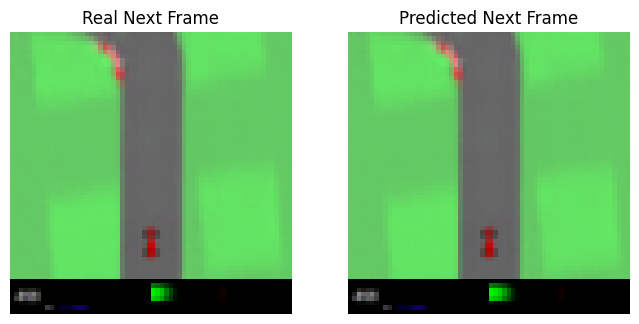

In [ ]:
import matplotlib.pyplot as plt

real_img = real_img.squeeze(0).cpu().permute(1,2,0)
pred_img = pred_img.squeeze(0).cpu().permute(1,2,0)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(real_img)
plt.title("Real Next Frame")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(pred_img)
plt.title("Predicted Next Frame")
plt.axis('off')
plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt

seq_len_test = 50

# take one sequence from loader
for z_seq, a_seq, z_next_seq, rewards in loader:
    z_seq = z_seq[0]           # [seq,512]
    a_seq = a_seq[0]           # [seq,3]
    z_next_seq = z_next_seq[0] # [seq,512]
    break

z_seq = z_seq.to(device)
a_seq = a_seq.to(device)
z_next_seq = z_next_seq.to(device)

# start from first real latent
z_current = z_seq[0]

pred_latents = []
real_latents = []

with torch.no_grad():

    for t in range(seq_len_test):

        action = a_seq[t]

        mu, sigma, pi, r_pred = model(
            z_current.unsqueeze(0).unsqueeze(0),
            action.unsqueeze(0).unsqueeze(0)
        )

        mixture_idx = torch.argmax(pi, dim=-1)

        z_pred = mu[0,0,:,mixture_idx[0,0]]

        pred_latents.append(z_pred)
        real_latents.append(z_next_seq[t])

        # feed predicted latent back
        z_current = z_pred

pred_latents = torch.stack(pred_latents)
real_latents = torch.stack(real_latents)

In [1]:
with torch.no_grad():

    real_imgs = vae1.decode(real_latents)
    pred_imgs = vae1.decode(pred_latents)

NameError: name 'torch' is not defined

In [ ]:
plt.figure(figsize=(20,4))

for i in range(10):

    real_img = real_imgs[i].cpu().permute(1,2,0)
    pred_img = pred_imgs[i].cpu().permute(1,2,0)

    plt.subplot(2,10,i+1)
    plt.imshow(real_img)
    plt.axis("off")

    plt.subplot(2,10,i+11)
    plt.imshow(pred_img)
    plt.axis("off")

plt.suptitle("Top: Real Frames | Bottom: Predicted Frames")
plt.show()

In [ ]:
mse = torch.mean((pred_latents - real_latents)**2)
print("Latent MSE:", mse.item())